# 3. Logistic Regression (Baseline)

Logistic Regression serves as our **baseline model**. It provides interpretable coefficients and a benchmark against which more complex models are compared.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('../').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import pickle

sns.set_style('whitegrid')

In [2]:
# Load preprocessed data
data = np.load('../data/preprocessed_data.npz')
X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']
feature_names = np.load('../data/feature_names.npy', allow_pickle=True)

print(f'Training set: {X_train.shape}')
print(f'Test set:     {X_test.shape}')

Training set: (16676, 17)
Test set:     (2466, 17)


In [3]:
from src.models import train_logistic_regression
from src.evaluation import compute_metrics, plot_confusion_matrix, plot_roc_curve

## 3.1 Model Training

In [4]:
lr_model = train_logistic_regression(X_train, y_train)

print('Logistic Regression Parameters:')
print(f'  class_weight: {lr_model.class_weight}')
print(f'  max_iter:     {lr_model.max_iter}')
print(f'  solver:       {lr_model.solver}')
print(f'  random_state: {lr_model.random_state}')
print(f'  n_features:   {lr_model.n_features_in_}')

Logistic Regression Parameters:
  class_weight: balanced
  max_iter:     1000
  solver:       lbfgs
  random_state: 42
  n_features:   17


## 3.2 Feature Importance (Coefficients)

Logistic Regression coefficients indicate the direction and strength of each feature's influence on the purchase probability. Positive coefficients increase the log-odds of purchase.

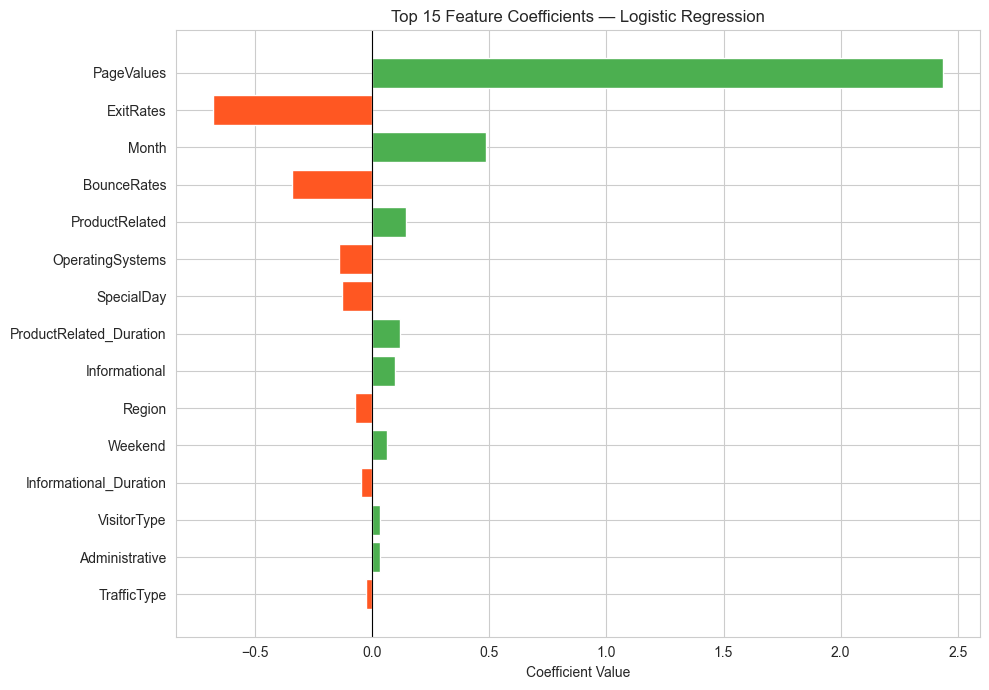


All coefficients (sorted by absolute value):
                Feature  Coefficient
                Browser    -0.009147
Administrative_Duration    -0.017107
            TrafficType    -0.023862
         Administrative     0.032902
            VisitorType     0.033155
 Informational_Duration    -0.048423
                Weekend     0.062374
                 Region    -0.071828
          Informational     0.098763
ProductRelated_Duration     0.119726
             SpecialDay    -0.125703
       OperatingSystems    -0.140595
         ProductRelated     0.146405
            BounceRates    -0.343120
                  Month     0.485214
              ExitRates    -0.678632
             PageValues     2.438526


In [5]:
# Feature coefficients
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_model.coef_[0]
})
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=True)

# Plot top 15
top_n = 15
top_df = coef_df.tail(top_n)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#FF5722' if c < 0 else '#4CAF50' for c in top_df['Coefficient']]
ax.barh(top_df['Feature'], top_df['Coefficient'], color=colors, edgecolor='white')
ax.set_xlabel('Coefficient Value')
ax.set_title(f'Top {top_n} Feature Coefficients — Logistic Regression')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print('\nAll coefficients (sorted by absolute value):')
print(coef_df[['Feature', 'Coefficient']].to_string(index=False))

## 3.3 Evaluation

In [6]:
lr_results = compute_metrics(lr_model, X_test, y_test, 'Logistic Regression')

print(f"Accuracy:  {lr_results['accuracy']:.4f}")
print(f"Precision: {lr_results['precision']:.4f}")
print(f"Recall:    {lr_results['recall']:.4f}")
print(f"F1-Score:  {lr_results['f1']:.4f}")
print(f"ROC-AUC:   {lr_results['roc_auc']:.4f}")
print(f"\nClassification Report:\n{lr_results['report']}")

Accuracy:  0.8593
Precision: 0.5348
Recall:    0.7042
F1-Score:  0.6079
ROC-AUC:   0.8801

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.89      0.91      2084
           1       0.53      0.70      0.61       382

    accuracy                           0.86      2466
   macro avg       0.74      0.80      0.76      2466
weighted avg       0.88      0.86      0.87      2466



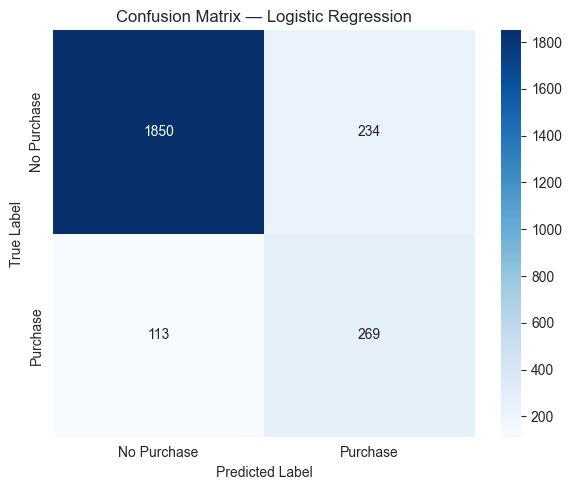

In [7]:
plot_confusion_matrix(y_test, lr_results['y_pred'], 'Logistic Regression')

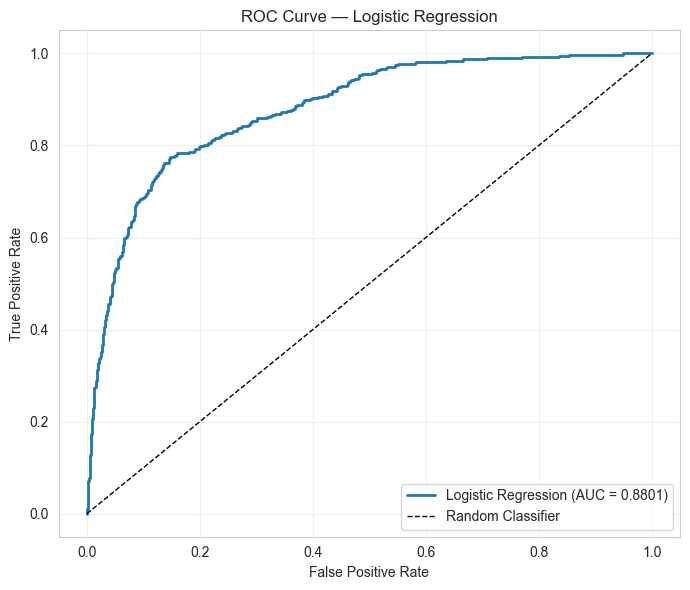

In [8]:
plot_roc_curve(y_test, lr_results['y_proba'], 'Logistic Regression')

## 3.4 Summary

**Logistic Regression** provides a solid interpretable baseline:

- The model identifies **PageValues** as the strongest predictor of purchase intent.
- Using `class_weight='balanced'` compensates for the class imbalance.
- Coefficients give clear directional interpretation (positive → more likely to purchase).
- This baseline will be compared against ANN and Random Forest in the final evaluation.

In [ ]:
# Save model and results
save_dir = Path('../data')
joblib.dump(lr_model, save_dir / 'lr_model.joblib')

# Save results
lr_results_save = {
    'model_name': lr_results['model_name'],
    'y_pred': lr_results['y_pred'],
    'y_proba': lr_results['y_proba'],
    'accuracy': lr_results['accuracy'],
    'precision': lr_results['precision'],
    'recall': lr_results['recall'],
    'f1': lr_results['f1'],
    'roc_auc': lr_results['roc_auc'],
}
with open(save_dir / 'lr_results.pkl', 'wb') as f:
    pickle.dump(lr_results_save, f)

print('Model and results saved.')

Model and results saved.
